# HalluCodeDetection — Phase 1, 3, and 4 Results

This notebook reads the project's persisted files. Run all cells after updating any phase to refresh tables, charts, and confusion matrices.

In [1]:
from __future__ import annotations

import json
import os
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'config.yaml').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

RESULTS_DIR = ROOT / 'data/results/evalplus'
BASE_PATH = RESULTS_DIR / 'dataset_base.json'
TRAINING_PATH = RESULTS_DIR / 'trained_models.jsonl'
EVALUATION_PATH = RESULTS_DIR / 'evaluation_results.jsonl'
LEVELS = ('correct', 'functional', 'runtime', 'syntax')
# The highest-priority error represents the primary class.
PRIMARY_ORDER = ('syntax', 'runtime', 'functional', 'correct')

def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

def format_pct(value: float | None) -> str:
    return '—' if value is None else f'{value * 100:.2f}%'

def format_duration(seconds: float | None) -> str:
    if seconds is None:
        return '—'
    hours, remainder = divmod(int(seconds), 3600)
    minutes, seconds = divmod(remainder, 60)
    return f'{hours:02d}:{minutes:02d}:{seconds:02d}'

def primary_label(levels: list[str]) -> str | None:
    values = set(levels or [])
    return next((level for level in PRIMARY_ORDER if level in values), None)

sns.set_theme(style='whitegrid', context='notebook')
print(f'Project root: {ROOT}')
print(f'Results directory: {RESULTS_DIR}')

Project root: /home/forcaaerea/Documentos/HalluCodeDetection
Results directory: /home/forcaaerea/Documentos/HalluCodeDetection/data/results/evalplus


## 1. Phase 1 — EVAL+ generation and execution

Each percentage is calculated over examples generated by that model. The row sum can exceed 100% because an example may receive multiple labels.

In [2]:
base_rows = read_jsonl(BASE_PATH)
config_data = yaml.safe_load((ROOT / 'config.yaml').read_text(encoding='utf-8'))
model_sizes = {}
for provider_models in config_data.get('models', {}).values():
    for model in provider_models:
        model_sizes[model['id']] = model.get('size')

phase1 = []
for model_id, group in pd.DataFrame(base_rows).groupby('model', sort=False):
    labels = Counter(
        level['level_name']
        for levels in group['levels']
        for level in levels
    )
    total = len(group)
    phase1.append({
        'Model': model_id,
        'Parameters': f"{model_sizes.get(model_id, '—')}B" if model_sizes.get(model_id) else '—',
        **{level.title(): format_pct(labels[level] / total) for level in LEVELS},
    })

display(pd.DataFrame(phase1))

,Model,Parameters,Correct,Functional,Runtime,Syntax
0,gpt-oss:20b,20B,79.04%,16.87%,5.33%,0.36%
1,gemma3:4b,4B,62.17%,32.50%,8.70%,0.00%
2,qwen2.5-coder:7b,7B,73.36%,20.96%,7.82%,0.00%
3,gemma4:31b,31B,78.69%,15.45%,3.91%,3.20%
4,muse-glimmer:30b,30B,80.82%,14.74%,4.26%,0.71%
5,qwen3.8:27b,27B,76.20%,19.36%,5.68%,0.00%
6,devstral-small-2:24b,24B,70.69%,24.33%,6.93%,0.36%
7,qwen2.5-coder:32b,32B,67.14%,25.40%,9.06%,0.53%
8,qwen3-coder:30b,30B,76.55%,17.58%,6.39%,0.53%
9,glm-4.7-flash:latest,30B,66.25%,28.60%,7.10%,0.18%


## 2. Current dataset distribution

The charts use the primary label (`level`) and the same task-grouped split used for training.

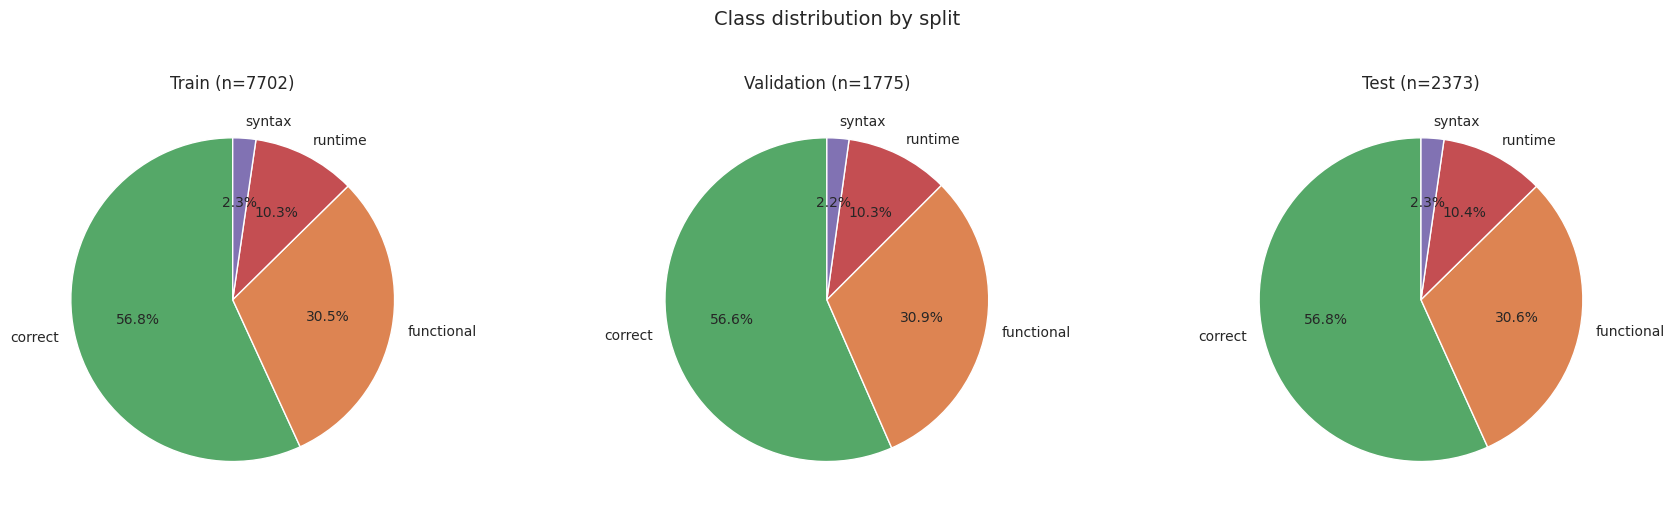

In [3]:
from src.constants import HalluCodeDetectionConfig
from src.dataset.judge_dataset import load_hallucination_dataset

project_config = HalluCodeDetectionConfig(str(ROOT / 'config.yaml'))
splits = load_hallucination_dataset(project_config)
colors = {'correct': '#55a868', 'functional': '#dd8452', 'runtime': '#c44e52', 'syntax': '#8172b3'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, split_name in zip(axes, ('train', 'validation', 'test')):
    records = splits[split_name].to_list()
    counts = Counter(
        record.get('level')
        or primary_label(record.get('levels', []))
        or primary_label(record.get('expected_levels', []))
        for record in records
    )
    values = [counts[level] for level in LEVELS if counts[level]]
    names = [level for level in LEVELS if counts[level]]
    axis.pie(
        values, labels=names, autopct='%1.1f%%', startangle=90,
        colors=[colors[level] for level in names], textprops={'fontsize': 10},
    )
    axis.set_title(f"{split_name.title()} (n={len(splits[split_name])})")
plt.suptitle('Class distribution by split', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Phase 3 — hyperparameter search

The table shows every completed training run in the JSONL. Macro F1 and Macro Recall are shown as `—` for historical runs that predate their recording.

In [4]:
training_rows = read_jsonl(TRAINING_PATH)
phase3 = []
for row in training_rows:
    model = row['model_name']['id'].removeprefix('google/')
    phase3.append({
        'Model': model,
        'LoRA parameters': f"r={row['lora_r']}; α={row['lora_alpha']}; dropout={row['lora_dropout']:g}",
        'Other parameters': f"lr={row['learning_rate']:g}; epochs={row['num_epochs']}; bias={row['bias']}",
        'Acc. Validation': format_pct(row.get('val_acc')),
        'Time': format_duration(row.get('training_time')),
    })

display(pd.DataFrame(phase3))

,Model,LoRA parameters,Other parameters,Acc. Validation,Time
0,gemma-4-E2B-it,r=8; α=16; dropout=0.05,lr=5e-05; epochs=3; bias=lora_only,58.37%,01:52:44
1,gemma-4-E4B-it,r=32; α=16; dropout=0.05,lr=0.0001; epochs=4; bias=all,63.72%,03:02:33
2,gemma-4-E2B-it,r=32; α=32; dropout=0.05,lr=5e-05; epochs=3; bias=none,59.55%,01:48:42
3,gemma-4-E2B-it,r=16; α=32; dropout=0.05,lr=0.0001; epochs=4; bias=all,62.37%,02:24:38
4,gemma-4-E4B-it,r=16; α=8; dropout=0.05,lr=5e-05; epochs=4; bias=lora_only,59.83%,03:22:51
5,gemma-4-E4B-it,r=16; α=16; dropout=0.1,lr=0.0001; epochs=3; bias=lora_only,64.85%,02:22:24
6,gemma-4-E2B-it,r=8; α=32; dropout=0.1,lr=5e-05; epochs=3; bias=all,57.75%,01:45:39
7,gemma-4-E4B-it,r=8; α=8; dropout=0.1,lr=0.0001; epochs=3; bias=none,63.77%,02:13:10
8,gemma-4-E4B-it,r=16; α=16; dropout=0.05,lr=0.0001; epochs=3; bias=lora_only,66.03%,02:30:38
9,gemma-4-E4B-it,r=16; α=16; dropout=0.1,lr=0.0001; epochs=4; bias=lora_only,64.11%,03:21:02


## 4. Phase 4 — evaluation

`% evaluated` is global coverage: the number of responses with a valid parser result divided by the evaluation experiment total. The notebook infers that total from persisted indexes and compares it with the current YAML split. Accuracy is exact label-set match; F1 and Recall are multilabel.

In [5]:
evaluation_rows = read_jsonl(EVALUATION_PATH)
latest = defaultdict(dict)
for row in evaluation_rows:
    latest[(row['model_id'], row['kind'])][row['sample_index']] = row

CURRENT_TEST_TOTAL = len(splits['test'])
PERSISTED_TEST_TOTAL = max(
    (sample_index for rows in latest.values() for sample_index in rows),
    default=-1,
) + 1
# Results may belong to a previous deterministic split. Use its global size
# so coverage never depends on an individual model's number of attempts.
TOTAL_TEST = max(CURRENT_TEST_TOTAL, PERSISTED_TEST_TOTAL)
phase4 = []
phase4_macro_comparison = []
for (model_id, kind), indexed_rows in sorted(latest.items()):
    rows = list(indexed_rows.values())
    parsed = sum(bool(row.get('judge_response', {}).get('analysis')) for row in rows)
    exact = sum(
        bool(row.get('predicted_levels'))
        and set(row.get('expected_levels', [])) == set(row.get('predicted_levels', []))
        for row in rows
    )
    precisions, recalls, f1s = {}, {}, {}
    for level in LEVELS:
        tp = fp = fn = 0
        for row in rows:
            expected = level in row.get('expected_levels', [])
            predicted = level in row.get('predicted_levels', [])
            tp += expected and predicted
            fp += (not expected) and predicted
            fn += expected and (not predicted)
        precisions[level] = tp / (tp + fp) if tp + fp else 0.0
        recalls[level] = tp / (tp + fn) if tp + fn else 0.0
        f1s[level] = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
    phase4.append({
        'Model': model_id.removeprefix('google/'),
        '% evaluated': format_pct(parsed / TOTAL_TEST),
        'Accuracy': format_pct(exact / len(rows)) if rows else '—',
        'Macro Precision': format_pct(np.mean(list(precisions.values()))),
        'Macro F1': format_pct(np.mean(list(f1s.values()))),
        'Macro Recall': format_pct(np.mean(list(recalls.values()))),
        **{f'Recall {level.title()}': format_pct(recalls[level]) for level in LEVELS},
    })
    non_syntax_levels = ('correct', 'functional', 'runtime')
    phase4_macro_comparison.append({
        'Model': model_id.removeprefix('google/'),
        'Macro Precision': format_pct(np.mean(list(precisions.values()))),
        'Macro Precision*': format_pct(np.mean([precisions[level] for level in non_syntax_levels])),
        'Macro F1': format_pct(np.mean(list(f1s.values()))),
        'Macro F1*': format_pct(np.mean([f1s[level] for level in non_syntax_levels])),
        'Macro Recall': format_pct(np.mean(list(recalls.values()))),
        'Macro Recall*': format_pct(np.mean([recalls[level] for level in non_syntax_levels])),
    })

display(pd.DataFrame(phase4))
display(Markdown('#### Macro metrics with and without Syntax'))
display(Markdown('`*` excludes the `syntax` class from the macro average; the unstarred metrics include all four classes.'))
display(pd.DataFrame(phase4_macro_comparison))
display(Markdown(f'**Global total used for coverage:** {TOTAL_TEST:,} examples.'))
if CURRENT_TEST_TOTAL != PERSISTED_TEST_TOTAL:
    display(Markdown(
        f'> ⚠️ The current split contains {CURRENT_TEST_TOTAL:,} examples, but persisted results ' 
        f'indicate {PERSISTED_TEST_TOTAL:,}. Coverage uses the larger total until evaluation is rerun.'))

,Model,% evaluated,Accuracy,Macro Precision,Macro F1,Macro Recall,Recall Correct,Recall Functional,Recall Runtime,Recall Syntax
0,devstral-small-2:24b,99.71%,53.93%,40.76%,38.07%,42.88%,54.89%,63.60%,17.72%,35.29%
1,gemma3:4b,99.92%,32.88%,33.65%,23.41%,32.81%,22.59%,84.68%,6.33%,17.65%
2,gemma4:31b,99.95%,72.41%,49.31%,48.50%,59.07%,83.67%,50.12%,24.05%,78.43%
3,gemma-3-4b-it,100.00%,38.46%,40.98%,26.71%,32.00%,30.00%,81.99%,10.13%,5.88%
4,gemma-4-E2B-it,92.92%,48.11%,47.82%,33.11%,33.89%,47.78%,65.44%,16.46%,5.88%
5,gemma-4-E4B-it,98.87%,45.86%,40.13%,37.03%,50.78%,38.00%,86.40%,31.65%,47.06%
6,gpt-oss:20b,40.52%,25.13%,51.23%,38.97%,44.68%,17.52%,55.76%,32.91%,72.55%
7,muse-glimmer:30b,91.74%,73.13%,59.42%,53.81%,54.69%,83.30%,55.51%,27.00%,52.94%
8,qwen2.5-coder:32b,58.14%,60.77%,48.82%,41.53%,50.99%,70.68%,37.55%,12.99%,82.76%
9,qwen2.5-coder:7b,99.92%,62.46%,41.75%,33.71%,34.80%,72.33%,46.69%,2.53%,17.65%


#### Macro metrics with and without Syntax

`*` excludes the `syntax` class from the macro average; the unstarred metrics include all four classes.

,Model,Macro Precision,Macro Precision*,Macro F1,Macro F1*,Macro Recall,Macro Recall*
0,devstral-small-2:24b,40.76%,48.89%,38.07%,43.30%,42.88%,45.40%
1,gemma3:4b,33.65%,41.93%,23.41%,27.30%,32.81%,37.87%
2,gemma4:31b,49.31%,60.39%,48.50%,55.78%,59.07%,52.61%
3,gemma-3-4b-it,40.98%,46.31%,26.71%,32.44%,32.00%,40.70%
4,gemma-4-E2B-it,47.82%,47.09%,33.11%,40.64%,33.89%,43.22%
5,gemma-4-E4B-it,40.13%,48.48%,37.03%,41.76%,50.78%,52.01%
6,gpt-oss:20b,51.23%,60.69%,38.97%,40.38%,44.68%,35.40%
7,muse-glimmer:30b,59.42%,71.86%,53.81%,61.35%,54.69%,55.27%
8,qwen2.5-coder:32b,48.82%,57.82%,41.53%,43.86%,50.99%,40.40%
9,qwen2.5-coder:7b,41.75%,50.40%,33.71%,39.40%,34.80%,40.52%


**Global total used for coverage:** 3,729 examples.

> ⚠️ The current split contains 2,373 examples, but persisted results indicate 3,729. Coverage uses the larger total until evaluation is rerun.

### Row-normalized confusion matrices: base and fine-tuned models

Only two 4×4 matrices are shown: the Gemma 4 E4B base model and its fine-tuned version, both against ground truth. Because the task is multilabel, each matrix uses a primary class with priority `syntax → runtime → functional → correct`; the metrics table above remains fully multilabel. Rows are normalized by the real class. Each cell reads `percentage\n(predictions / real-row total)`: for real X cases, Y was predicted at that percentage. Responses without a valid parsed class are excluded from these matrices and remain visible in `% evaluated`.

#### Precision and Recall: base vs. fine-tuned

,Model,Precision Correct,Precision Functional,Precision Runtime,Precision Syntax,Recall Correct,Recall Functional,Recall Runtime,Recall Syntax,Macro Precision,Macro Recall
0,Gemma 4 E4B base,93.44%,32.15%,19.84%,15.09%,38.00%,86.40%,31.65%,47.06%,40.13%,50.78%
1,Gemma 4 E4B fine-tuned,88.99%,56.29%,70.97%,18.18%,85.33%,69.12%,27.85%,11.76%,58.61%,48.52%


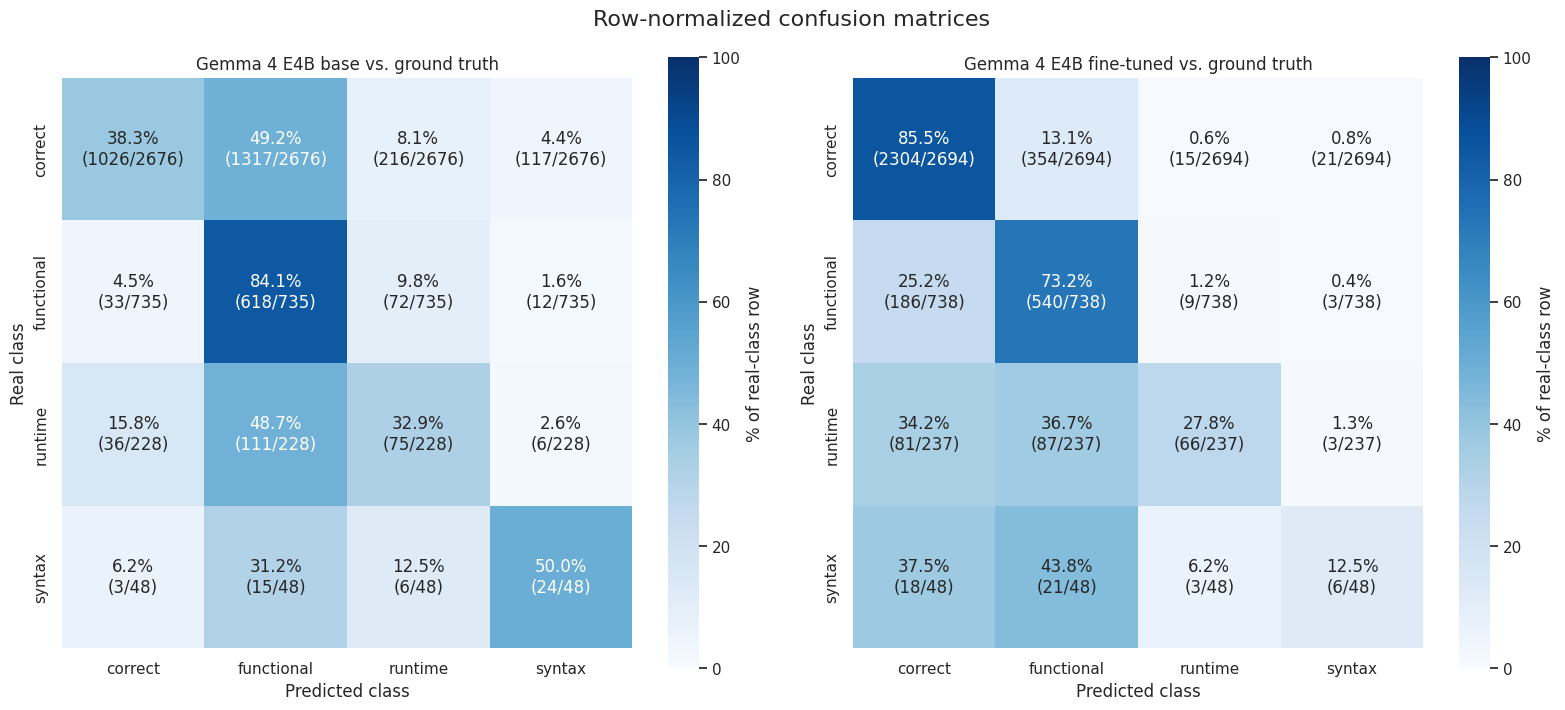

In [6]:
BASE_MODEL = ('google/gemma-4-E4B-it', 'gemma')
TRAINED_MODEL = ('trained/gemma-4-e4b-best', 'gemma')

def row_normalized_matrix(model_key):
    pairs = [
        (primary_label(row.get('expected_levels', [])), primary_label(row.get('predicted_levels', [])))
        for row in latest[model_key].values()
    ]
    pairs = [(actual, predicted) for actual, predicted in pairs if actual and predicted]
    counts = pd.crosstab(
        pd.Categorical([actual for actual, _ in pairs], categories=LEVELS),
        pd.Categorical([predicted for _, predicted in pairs], categories=LEVELS),
        dropna=False,
    )
    row_totals = counts.sum(axis=1)
    percentages = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100
    annotations = np.empty(counts.shape, dtype=object)
    for row_index, actual in enumerate(LEVELS):
        for column_index, predicted in enumerate(LEVELS):
            annotations[row_index, column_index] = (
                f"{percentages.loc[actual, predicted]:.1f}%\n"
                f"({counts.loc[actual, predicted]}/{row_totals.loc[actual]})"
            )
    return percentages, annotations

available = [(BASE_MODEL, 'Gemma 4 E4B base'), (TRAINED_MODEL, 'Gemma 4 E4B fine-tuned')]

def precision_recall_summary(model_key, title):
    precisions, recalls = {}, {}
    rows = latest[model_key].values()
    for level in LEVELS:
        tp = fp = fn = 0
        for row in rows:
            expected = level in row.get('expected_levels', [])
            predicted = level in row.get('predicted_levels', [])
            tp += expected and predicted
            fp += (not expected) and predicted
            fn += expected and (not predicted)
        precisions[level] = tp / (tp + fp) if tp + fp else 0.0
        recalls[level] = tp / (tp + fn) if tp + fn else 0.0
    return {
        'Model': title,
        **{f'Precision {level.title()}': format_pct(precisions[level]) for level in LEVELS},
        **{f'Recall {level.title()}': format_pct(recalls[level]) for level in LEVELS},
        'Macro Precision': format_pct(np.mean(list(precisions.values()))),
        'Macro Recall': format_pct(np.mean(list(recalls.values()))),
    }

if all(key in latest for key, _ in available):
    display(Markdown('#### Precision and Recall: base vs. fine-tuned'))
    display(pd.DataFrame([
        precision_recall_summary(model_key, title) for model_key, title in available
    ]))

missing = [name for key, name in available if key not in latest]
if missing:
    print(f"Missing persisted results: {', '.join(missing)}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for axis, (model_key, title) in zip(axes, available):
        percentages, annotations = row_normalized_matrix(model_key)
        sns.heatmap(
            percentages, annot=annotations, fmt='', cmap='Blues', vmin=0, vmax=100,
            cbar_kws={'label': '% of real-class row'}, square=True, ax=axis,
        )
        axis.set_title(f'{title} vs. ground truth')
        axis.set_xlabel('Predicted class')
        axis.set_ylabel('Real class')
    plt.suptitle('Row-normalized confusion matrices', y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

### Base vs. fine-tuned predictions

This additional matrix compares the primary predictions of the base and fine-tuned models on their shared valid samples. For a row X and column Y with value Z%, read the cell as: **among base predictions of X, the fine-tuned model predicted Y Z% of the time**. The count below the percentage is `fine-tuned predictions for Y / total base predictions of X`.

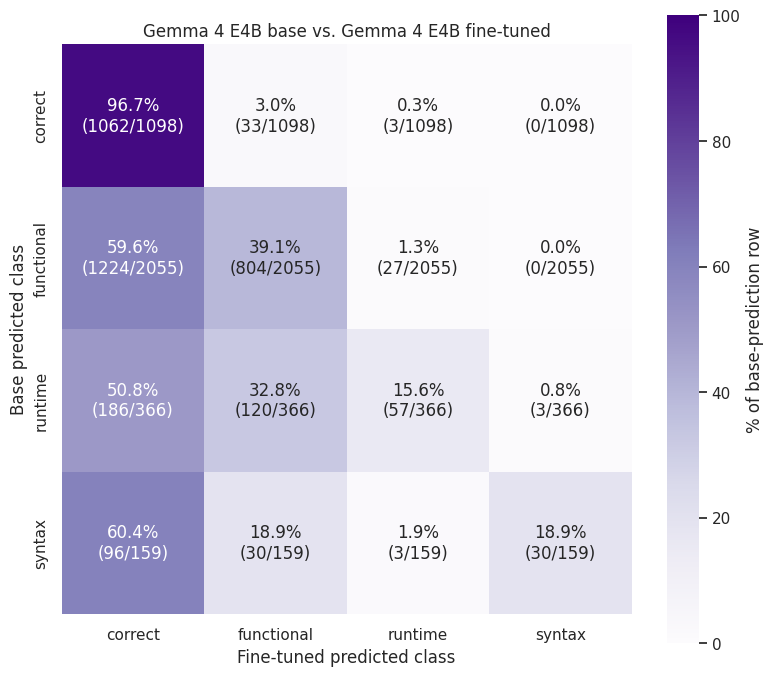

In [7]:
if BASE_MODEL not in latest or TRAINED_MODEL not in latest:
    print('Base-model or fine-tuned-model results are not available.')
else:
    common_indices = sorted(set(latest[BASE_MODEL]) & set(latest[TRAINED_MODEL]))
    pairs = [
        (
            primary_label(latest[BASE_MODEL][index].get('predicted_levels', [])),
            primary_label(latest[TRAINED_MODEL][index].get('predicted_levels', [])),
        )
        for index in common_indices
    ]
    pairs = [(base, trained) for base, trained in pairs if base and trained]
    counts = pd.crosstab(
        pd.Categorical([base for base, _ in pairs], categories=LEVELS),
        pd.Categorical([trained for _, trained in pairs], categories=LEVELS),
        dropna=False,
    )
    row_totals = counts.sum(axis=1)
    percentages = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100
    annotations = np.empty(counts.shape, dtype=object)
    for row_index, base in enumerate(LEVELS):
        for column_index, trained in enumerate(LEVELS):
            annotations[row_index, column_index] = (
                f"{percentages.loc[base, trained]:.1f}%\n"
                f"({counts.loc[base, trained]}/{row_totals.loc[base]})"
            )
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        percentages, annot=annotations, fmt='', cmap='Purples', vmin=0, vmax=100,
        cbar_kws={'label': '% of base-prediction row'}, square=True,
    )
    plt.title('Gemma 4 E4B base vs. Gemma 4 E4B fine-tuned')
    plt.xlabel('Fine-tuned predicted class')
    plt.ylabel('Base predicted class')
    plt.tight_layout()
    plt.show()